In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

### PCA and Dimensionality Reduction

Original data shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Covariance Matrix shape: (4, 4)

Eigenvalues (variance explained):
  PC1: 2.9381 (72.96%)
  PC2: 0.9202 (22.85%)
  PC3: 0.1477 (3.67%)
  PC4: 0.0209 (0.52%)

Reduced data shape: (150, 2)


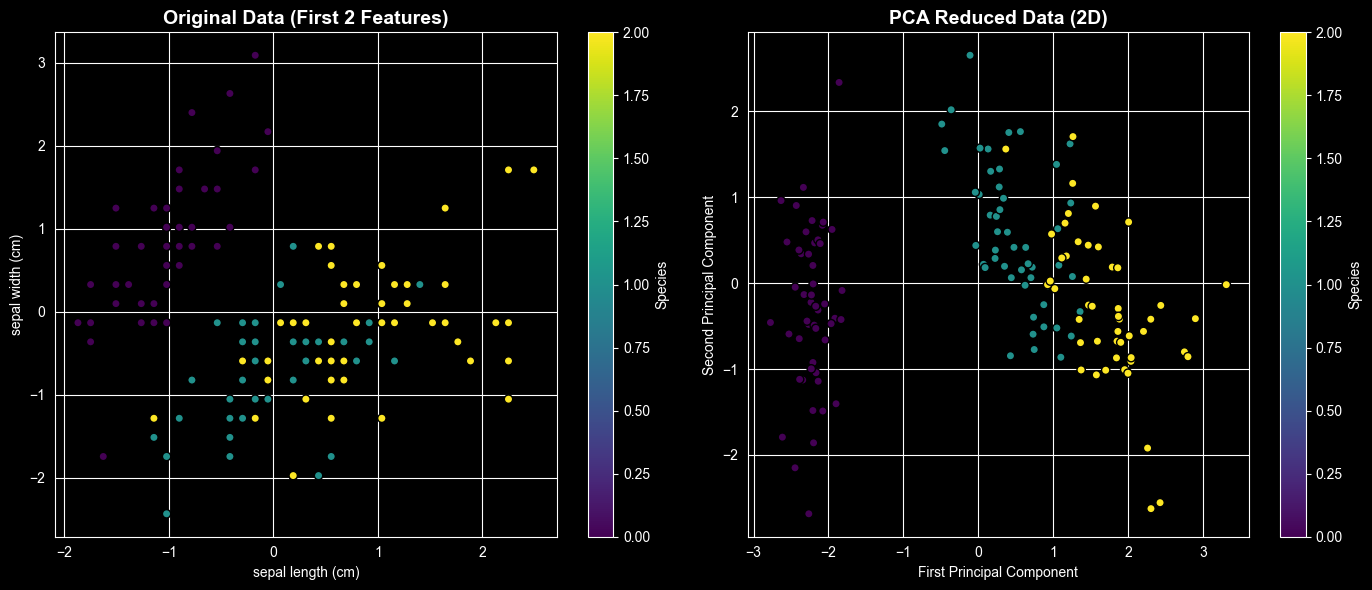

Saved to: task6_pca_visualization.png


In [2]:
def spectral_decomposition(a):
    # Compute eigenvalues and eigenvectors
    eigen_values, eigen_vectors = np.linalg.eig(a)

    # Construct diagonal matrix of eigenvalues
    lambda_mat = np.diag(eigen_values)

    # Reconstruct matrix: A = Q * Lambda_mat * Q^(-1)
    q = eigen_vectors
    q_inv = np.linalg.inv(q)
    mat_reconstructed = q @ lambda_mat @ q_inv

    return eigen_values, eigen_vectors, mat_reconstructed

# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

print(f"Original data shape: {X.shape}")
print(f"Features: {feature_names}")

# Standardize the data
X_scaled = StandardScaler().fit_transform(X)

# Compute covariance matrix
cov_matrix = np.cov(X_scaled.T)
print(f"\nCovariance Matrix shape: {cov_matrix.shape}")

# Spectral decomposition of covariance matrix
eigenvalues_pca, eigenvectors_pca, _ = spectral_decomposition(cov_matrix)

# Sort by eigenvalues descending
idx = eigenvalues_pca.argsort()[::-1]
eigenvalues_pca = eigenvalues_pca[idx]
eigenvectors_pca = eigenvectors_pca[:, idx]

print(f"\nEigenvalues (variance explained):")
for i, ev in enumerate(eigenvalues_pca):
    print(f"  PC{i+1}: {ev:.4f} ({ev/eigenvalues_pca.sum()*100:.2f}%)")

# Project data onto the first 2 principal components
W = eigenvectors_pca[:, :2]
X_pca = X_scaled @ W

print(f"\nReduced data shape: {X_pca.shape}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original data (first two features)
ax1 = axes[0]
scatter1 = ax1.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='viridis', edgecolor='k')
ax1.set_xlabel(feature_names[0])
ax1.set_ylabel(feature_names[1])
ax1.set_title('Original Data (First 2 Features)', fontsize=14, fontweight='bold')
plt.colorbar(scatter1, ax=ax1, label='Species')

# PCA reduced data
ax2 = axes[1]
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k')
ax2.set_xlabel('First Principal Component')
ax2.set_ylabel('Second Principal Component')
ax2.set_title('PCA Reduced Data (2D)', fontsize=14, fontweight='bold')
plt.colorbar(scatter2, ax=ax2, label='Species')

plt.tight_layout()
output_dir = Path.cwd() / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)

output_file = output_dir / "task6_pca_visualization.png"
plt.savefig(output_file, dpi=150, bbox_inches='tight')
plt.show()

print("Saved to: task6_pca_visualization.png")